<a href="https://qworld.net" target="_blank" align="left"><img src="../../qworld/images/header.jpg"  align="left"></a>
$ \newcommand{\bra}[1]{\langle #1|} $
$ \newcommand{\ket}[1]{|#1\rangle} $
$ \newcommand{\braket}[2]{\langle #1|#2\rangle} $
$ \newcommand{\dot}[2]{ #1 \cdot #2} $
$ \newcommand{\biginner}[2]{\left\langle #1,#2\right\rangle} $
$ \newcommand{\mymatrix}[2]{\left( \begin{array}{#1} #2\end{array} \right)} $
$ \newcommand{\myvector}[1]{\mymatrix{c}{#1}} $
$ \newcommand{\myrvector}[1]{\mymatrix{r}{#1}} $
$ \newcommand{\mypar}[1]{\left( #1 \right)} $
$ \newcommand{\mybigpar}[1]{ \Big( #1 \Big)} $
$ \newcommand{\sqrttwo}{\frac{1}{\sqrt{2}}} $
$ \newcommand{\dsqrttwo}{\dfrac{1}{\sqrt{2}}} $
$ \newcommand{\onehalf}{\frac{1}{2}} $
$ \newcommand{\donehalf}{\dfrac{1}{2}} $
$ \newcommand{\hadamard}{ \mymatrix{rr}{ \sqrttwo & \sqrttwo \\ \sqrttwo & -\sqrttwo }} $
$ \newcommand{\vzero}{\myvector{1\\0}} $
$ \newcommand{\vone}{\myvector{0\\1}} $
$ \newcommand{\stateplus}{\myvector{ \sqrttwo \\  \sqrttwo } } $
$ \newcommand{\stateminus}{ \myrvector{ \sqrttwo \\ -\sqrttwo } } $
$ \newcommand{\myarray}[2]{ \begin{array}{#1}#2\end{array}} $
$ \newcommand{\X}{ \mymatrix{cc}{0 & 1 \\ 1 & 0}  } $
$ \newcommand{\I}{ \mymatrix{rr}{1 & 0 \\ 0 & 1}  } $
$ \newcommand{\Z}{ \mymatrix{rr}{1 & 0 \\ 0 & -1}  } $
$ \newcommand{\Htwo}{ \mymatrix{rrrr}{ \frac{1}{2} & \frac{1}{2} & \frac{1}{2} & \frac{1}{2} \\ \frac{1}{2} & -\frac{1}{2} & \frac{1}{2} & -\frac{1}{2} \\ \frac{1}{2} & \frac{1}{2} & -\frac{1}{2} & -\frac{1}{2} \\ \frac{1}{2} & -\frac{1}{2} & -\frac{1}{2} & \frac{1}{2} } } $
$ \newcommand{\CNOT}{ \mymatrix{cccc}{1 & 0 & 0 & 0 \\ 0 & 1 & 0 & 0 \\ 0 & 0 & 0 & 1 \\ 0 & 0 & 1 & 0} } $
$ \newcommand{\norm}[1]{ \left\lVert #1 \right\rVert } $
$ \newcommand{\pstate}[1]{ \lceil \mspace{-1mu} #1 \mspace{-1.5mu} \rfloor } $
$ \newcommand{\greenbit}[1] {\mathbf{{\color{green}#1}}} $
$ \newcommand{\bluebit}[1] {\mathbf{{\color{blue}#1}}} $
$ \newcommand{\redbit}[1] {\mathbf{{\color{red}#1}}} $
$ \newcommand{\brownbit}[1] {\mathbf{{\color{brown}#1}}} $
$ \newcommand{\blackbit}[1] {\mathbf{{\color{black}#1}}} $

# Feature Maps and Encoding Choices

_Prepared by Claudia Zendejas-Morales_

In hybrid QML, the first quantum modeling decision is how classical information is loaded into a quantum state. This step is usually called a **feature map** or **data encoding**. It is not a neutral technicality: the encoding determines which patterns are easy or hard for the circuit to represent, how many qubits are needed, and what preprocessing must be done before the quantum model even starts to learn.

To keep the tutorial formal and consistent, we introduce a clear notation for datasets, feature maps, and encoded quantum states.

In this notebook we focus on three of the most frequent encoding families for classical data in QML: **angle encoding**, **amplitude encoding**, and **basis encoding**. We keep the discussion centered on separable encodings and practical design choices. Entangling feature maps and data re-uploading will be developed in the next notebook.


## Why feature maps matter

A classical ML model receives vectors such as $\vec{x} \in \mathbb{R}^d$ directly. A quantum model does not: it acts on quantum states. So before a quantum circuit can process a classical sample, the sample must be mapped into a state

$$
|\psi(\vec{x})\rangle = U_F(\vec{x}) |0\rangle^{\otimes n}
$$

where $U_F(\vec{x})$ is the feature map and $n$ is the number of qubits used by the encoding.

This immediately raises practical questions:
- How many qubits are needed to represent one sample?
- Does the data need scaling, normalization, padding, or binarization?
- Is the encoding easy to implement on near-term hardware?
- Does the encoding preserve the information we care about for the task?

A good way to organize the full variational-model pipeline is:
- **Feature map**: depends on the input data $\vec{x}$.
- **Ansatz**: depends on trainable parameters $\boldsymbol{\theta}$.
- **Measurement/readout**: turns the final state into classical outputs.

This notebook focuses only on the first part.


<p align="center">
  <img align="center" style="display:block; margin-left: auto; margin-right: auto;" src="./images/feature-map-ansatz-readout-pipeline.png" alt="Feature map, ansatz, and measurement pipeline" width="700"/>
</p>

This schematic shows the overall hybrid workflow: the **feature map** loads the classical input into a quantum state, the **ansatz** processes that state with trainable parameters, and the **measurement/readout** returns classical outputs.


<div style="background:#fff1d6;color:#111111;border-left:6px solid #d98500;padding:12px 14px;border-radius:6px;">
<b>Encoding is a modeling choice</b><br>
Two QML models may use the same ansatz and the same optimizer but behave very differently if they encode the data differently. In QML, the feature map is part of the hypothesis class, not only a preprocessing step.
</div>


<div style="background:#fff1d6;color:#111111;border-left:6px solid #d98500;padding:12px 14px;border-radius:6px;">
<b>What do $d$ and $n$ mean?</b><br>
The symbol $d$ denotes the <b>classical feature dimension</b>: if $\vec{x} \in \mathbb{R}^d$, then each sample has $d$ real components. The symbol $n$ denotes the <b>number of qubits</b> used by the encoding circuit. These two numbers do not have to be equal.<br><br>
For example, simple angle encoding often uses about one qubit per feature, so $n \approx d$. Amplitude encoding can store a length-$d$ vector using about $n = \lceil \log_2 d \rceil$ qubits, after normalization and usually padding to a power of two. Later in the tutorial we will also see settings where the same qubits are reused across layers, so the relation between $d$ and $n$ becomes even less direct.
</div>


## From classical features to quantum states

In machine learning, we usually start from a **dataset**: a collection of samples describing the system, object, or process that we want to model. Each sample is represented by a vector of **features**, and each feature captures one measurable or relevant aspect of the data. In other words, a dataset is made of many samples, and each sample is itself a structured list of features.

To describe this formally, we write the dataset as

$$
D := (\vec{x}^1, \dots, \vec{x}^M)
$$

where each $\vec{x}^j$ is the $j$-th sample in the dataset, with $j = 1, \dots, M$. Each sample is a feature vector of the form

$$
\vec{x}^j := (x_1^j, \dots, x_d^j) \in \mathbb{R}^d
$$

so every sample contains $d$ real-valued features that represent the data to be modeled.

<p align="center">
  <img align="center" style="display:block; margin-left: auto; margin-right: auto;" src="./images/feature-map-dataset-samples-features.png" alt="Dataset made of samples, each sample made of features" width="450"/>
</p>

<div style="background:#fff1d6;color:#111111;border-left:6px solid #d98500;padding:12px 14px;border-radius:6px;">
<b>How do the indices work?</b><br>
The superscript in $\vec{x}^j$ identifies a particular <b>sample</b> in the dataset. A generic sample is labeled by $j$, and the dataset contains $M$ samples in total, so $j = 1, \dots, M$. The subscript in $x_i^j$ identifies a particular <b>feature</b> inside that sample. A generic feature is labeled by $i$, and each sample contains $d$ features in total, so $i = 1, \dots, d$.
</div>

<br><br>

A feature map is a data-dependent state-preparation rule. In circuit language, it is convenient to write it as a unitary $U_F(\vec{x})$ acting on the reference state:

$$
|\psi(\vec{x})\rangle = U_F(\vec{x}) |0\rangle^{\otimes n}
$$

After encoding, a variational circuit $U_A(\boldsymbol{\theta})$ processes the state:

$$
|\psi_{\mathrm{out}}(\vec{x}, \boldsymbol{\theta})\rangle = U_A(\boldsymbol{\theta}) |\psi(\vec{x})\rangle
$$

In this notebook we focus on three common encoding families for classical data in QML: **angle encoding**, where real-valued features control gate angles; **amplitude encoding**, where vector entries are stored in amplitudes; and **basis encoding**, where binary or discrete values are mapped to computational-basis states.

These encodings differ in qubit efficiency, state-preparation cost, and preprocessing requirements. That tradeoff is central to QML: an encoding may be compact in qubit count but expensive in circuit preparation, or simple to prepare but qubit-hungry.


## Angle encoding

Angle encoding, also called **rotation encoding**, maps each feature value to the angle of a single-qubit rotation gate. A simple one-feature example uses a rotation around the $y$ axis:

$$
|0\rangle \xrightarrow{R_y(\theta)} \cos\left(\frac{\theta}{2}\right)|0\rangle + \sin\left(\frac{\theta}{2}\right)|1\rangle
$$

For a $d$-feature dataset, a common formal map is

$$
\vec{x}^j \mapsto \bigotimes_{i=1}^{d} \left( \cos \left(\frac{\varphi^j_i}{2} \right) |0\rangle + \sin \left(\frac{\varphi^j_i}{2} \right) |1\rangle \right)
$$

where the angles are obtained from the classical features through a scaling rule such as

$$
\varphi_i^j = \frac{x_i^j - x_i^{\min}}{x_i^{\max} - x_i^{\min}}\pi
$$

with $x_i^{\min} = \min_j x_i^j$ and $x_i^{\max} = \max_j x_i^j$. This keeps $\varphi_i^j \in [0,\pi]$, which is a natural range for $R_y$-based state preparation and helps avoid unnecessary aliasing from the periodicity of rotation gates.

Here the index $i$ is kept fixed, because we are looking at one particular feature at a time, while the minimization and maximization run over $j$, that is, over all samples in the dataset. So $x_i^{\min}$ and $x_i^{\max}$ are the minimum and maximum values attained by feature $i$ across the full dataset, not across different features inside one sample.

If a single scaled feature $x \in [0,1]$ is mapped to $\theta = \pi x$, then the probability of measuring state $|1\rangle$ is

$$
P(1) = \sin^2\left(\frac{\pi x}{2}\right)
$$

This already shows an important point: measured probabilities are nonlinear functions of the encoded feature even though the gate itself is linear as a quantum operator.

In its simplest form, angle encoding uses one qubit per feature. That makes it easy to interpret and easy to implement on NISQ devices, which is why it is often the default starting point for continuous classical data.


<p align="center">
  <img align="center" style="display:block; margin-left: auto; margin-right: auto;" src="./images/feature-map-angle-encoding.png" alt="Angle encoding with single-qubit rotations" width="700"/>
</p>

A simple rotation-based feature map is usually the most hardware-friendly starting point for classical tabular data with continuous features. In practice, if one wants to encode data with $R_z$ rotations, it is common to apply Hadamard gates first: otherwise an $R_z$ gate acting directly on $|0\rangle$ only adds a global phase, so it does not produce an observable effect in standard computational-basis measurements.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector


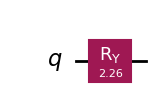

Encoded feature x = 0.72
Rotation angle theta = 2.2619 rad
Statevector amplitudes: [0.4258+0.j 0.9048+0.j]
Measurement probabilities: {np.str_('0'): np.float64(0.1813), np.str_('1'): np.float64(0.8187)}


In [2]:
def minmax_to_pi(x, x_min, x_max):
    # Map a real feature to an angle in [0, pi]
    return np.pi * (x - x_min) / (x_max - x_min)


x = 0.72
theta = minmax_to_pi(x, x_min=0.0, x_max=1.0)

qc_angle = QuantumCircuit(1)
qc_angle.ry(theta, 0)

sv_angle = Statevector.from_instruction(qc_angle)
probs_angle = sv_angle.probabilities_dict()

display(qc_angle.draw("mpl"))
print(f"Encoded feature x = {x:.2f}")
print(f"Rotation angle theta = {theta:.4f} rad")
print("Statevector amplitudes:", np.round(sv_angle.data, 4))
print("Measurement probabilities:", {k: round(v, 4) for k, v in probs_angle.items()})


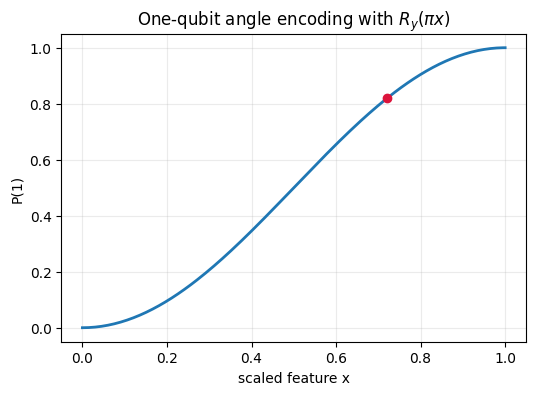

In [3]:
x_grid = np.linspace(0.0, 1.0, 200)
theta_grid = minmax_to_pi(x_grid, x_min=0.0, x_max=1.0)
p1_grid = np.sin(theta_grid / 2.0) ** 2

plt.figure(figsize=(6, 4))
plt.plot(x_grid, p1_grid, lw=2)
plt.scatter([x], [np.sin(theta / 2.0) ** 2], color="crimson", zorder=3)
plt.xlabel("scaled feature x")
plt.ylabel("P(1)")
plt.title("One-qubit angle encoding with $R_y(\\pi x)$")
plt.grid(alpha=0.25)
plt.show()


The plot shows why scaling matters. If we decide that a feature should live in $[0,1]$ and map it to $[0,\pi]$, then the circuit uses that interval in a controlled and interpretable way. If we feed raw numbers directly as angles, the periodicity of rotation gates can make distant raw values look artificially similar.

A second practical point is that not every rotation is informative from the all-zero state. For example, using only $R_z(\phi)$ on $|0\rangle$ changes the phase of $|0\rangle$ but does not change measurement probabilities in the computational basis. That is why phase-based encodings usually start by creating superposition first, for example with a Hadamard gate.


### Task 1 (coding): Why scaling matters in angle encoding

Use the example above as a template, but now compare two angle-encoding choices on the same raw feature values.

Use a dense set of raw values, for example `raw_values = np.linspace(0.0, 10.0, 101)`, so that the effect of periodicity becomes clearly visible.

For each value, compute $P(1)$ under both strategies:
- **Naive encoding**: use `theta = x` directly.
- **Scaled encoding**: map the full interval `[0, 10]` to `[0, pi]`.

Tasks:
- Build a one-qubit `R_y` circuit for each raw value in both strategies.
- Compute the probability of measuring `1` in both cases.
- Plot both curves on the same figure.
- Write 2-3 lines explaining why the scaled version is easier to interpret for classical data preprocessing.


<div style="background:#e8f1ff;color:#111111;border-left:6px solid #2f6fed;padding:12px 14px;border-radius:6px;">
<b>Task 1 solution:</b> <a href="01-feature-maps-and-encoding-choices-solutions.ipynb#task1-solution">Click here for Task 1 solution</a>
</div>


In [4]:
# Task 1 starter
raw_values = np.linspace(0.0, 10.0, 101)

# TODO:
# 1. Build a helper function that returns P(1) from a one-qubit R_y circuit.
# 2. Evaluate P(1) with theta = x (naive encoding).
# 3. Evaluate P(1) with theta obtained by mapping [0, 10] to [0, pi].
# 4. Plot both results on the same axes.
# 5. Write a short conclusion about periodicity and interpretability.


## A useful extension: two real features on one qubit

A pure one-qubit state depends on two angles on the Bloch sphere:

$$
|\psi\rangle = \cos\left(\frac{\theta}{2} \right) |0\rangle + e^{i\phi}\sin \left(\frac{\theta}{2} \right) |1\rangle
$$

This suggests a useful extension of angle encoding. If a sample contains $2n$ real features, equivalently if the input dimension is $d = 2n$, one convenient phase-aware map is

$$
\vec{x}^j \mapsto \bigotimes_{q=1}^{n} \left( \cos \left(\frac{\varphi^j_{2q-1}}{2} \right) |0\rangle + e^{i\varphi^j_{2q}} \sin \left(\frac{\varphi^j_{2q-1}}{2} \right) |1\rangle \right)
$$

The indices are worth reading carefully. The superscript $j$ still labels the sample, so all angles in the expression come from the same sample $\vec{x}^j$. The index $q$ labels the qubit, and qubit $q$ receives a pair of scaled features: the odd-indexed quantity $\varphi_{2q-1}^j$ controls the amplitudes through the factors $\cos(\varphi_{2q-1}^j/2)$ and $\sin(\varphi_{2q-1}^j/2)$, while the even-indexed quantity $\varphi_{2q}^j$ appears in the phase factor $e^{i\varphi_{2q}^j}$.

So each qubit stores two real numbers from the sample: one through the polar-angle part of the state and one through the azimuthal-phase part. That is why this scheme can encode up to $2n$ real features with $n$ qubits: qubit $1$ carries features $(1,2)$, qubit $2$ carries features $(3,4)$, and in general qubit $q$ carries features $(2q-1, 2q)$.

The practical caveat is important: a phase gate applied to $|0\rangle$ alone is not directly visible in computational-basis measurements. So the second angle is useful only when the circuit and the measurement strategy preserve sensitivity to phase. That is one reason why more deliberate phase-sensitive and entangling feature maps are deferred to the next notebook.


<p align="center">
  <img align="center" style="display:block; margin-left: auto; margin-right: auto;" src="./images/feature-map-two-features-one-qubit.png" alt="Two real features encoded on one qubit" width="500"/>
</p>

Using both Bloch-sphere angles can improve qubit efficiency, but only if later operations and measurements actually exploit the encoded phase information. We will return to that point when discussing entangling feature maps in the next notebook and when studying measurement and readout later in this section.


## Amplitude encoding

Amplitude encoding represents data points as the amplitudes of a multi-qubit quantum state. If the input vector has feature dimension $d$, then the cleanest amplitude-encoding setting is the case $d = N = 2^n$, where $N$ is the size of the computational basis of an $n$-qubit register. In that ideal case, the required number of qubits is $n = \log_2 d$. More generally, if the feature dimension is not exactly a power of two, then one usually needs about $n = \lceil \log_2 d \rceil$ qubits so that the amplitude space is large enough to contain the vector after padding if necessary. In other words, here we are considering the situation in which the classical feature dimension matches the amplitude-space dimension available on $n$ qubits.

For a particular sample, it is helpful to keep the sample index explicit and write

$$
\vec{x}^{\,j} = \bigl(x_0^{j}, x_1^{j}, \dots, x_{N-1}^{j}\bigr) \in \mathbb{R}^{N}
$$

Here the superscript $j$ labels the sample, while the subscripts $0,1,\dots,N-1$ label the components (features) of that sample. In this subsection we use indexing from $0$ to $N-1$ because it matches the computational-basis labels $|0\rangle, |1\rangle, \dots, |N-1\rangle$.

The amplitude-encoding map is then

$$
|\psi(\vec{x}^{\,j}) \rangle
\;=\; \frac{1}{\sqrt{\sum_{\ell=0}^{N-1} \left(x_{\ell}^{j}\right)^2}} \; \sum_{\ell=0}^{N - 1} x_{\ell}^{j} \,| \ell \rangle
$$

Here the sample $\vec{x}^{\,j}$ is loaded into computational-basis amplitudes, and the normalization factor is required to guarantee that the result is a valid quantum state.

For classical datasets we usually take $\vec{x}^{\,j} \in \mathbb{R}^N$, although the formal definition also extends to complex amplitudes.

<div style="background:#fff1d6;color:#111111;border-left:6px solid #d98500;padding:12px 14px;border-radius:6px;">
<b>What if $d$ is not exactly $2^n$?</b><br>
Amplitude encoding does <b>not</b> require the number of meaningful features to be exactly equal to $2^n$. What we need is an $n$-qubit amplitude space of size $N = 2^n$ large enough to hold the data. If $d < N$, we can pad the sample vector with zeros until it has length $N$. Those extra slots do not carry new information; they are simply unused amplitudes. If $d > N$, then $n$ qubits are not enough to store the full vector directly, so we must either increase the number of qubits or reduce the feature dimension before encoding.
</div>

<br>

The appealing part is the qubit count: a vector of dimension $2^n$ fits into only $n$ qubits. The difficult part is state preparation: building an arbitrary amplitude-encoded state can require nontrivial circuits, so qubit efficiency does not automatically imply low runtime or shallow depth.


<p align="center">
  <img align="center" style="display:block; margin-left: auto; margin-right: auto;" src="./images/feature-map-amplitude-encoding.png" alt="Amplitude encoding into a multi-qubit state" width="550"/>
</p>

Amplitude encoding is the standard example of qubit-efficient data loading, but one should always ask whether the preparation cost is realistic for the task. The circuit shown in this figure should be read as a small illustrative example, not as evidence that arbitrary amplitude encoding is generically cheap. For low-dimensional vectors or carefully chosen examples, the preparation can look compact; the difficulty appears when one asks for exact loading of general high-dimensional vectors, where the synthesized circuit can become much larger.


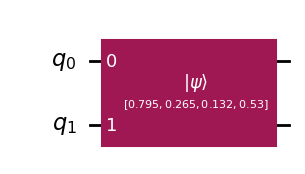

Normalized vector: [0.7947 0.2649 0.1325 0.5298]
Statevector amplitudes: [0.7947+0.j 0.2649+0.j 0.1325+0.j 0.5298+0.j]
Measurement probabilities: {np.str_('00'): np.float64(0.6316), np.str_('01'): np.float64(0.0702), np.str_('10'): np.float64(0.0175), np.str_('11'): np.float64(0.2807)}


In [5]:
raw_vector = np.array([3.0, 1.0, 0.5, 2.0])
amp_vector = raw_vector / np.linalg.norm(raw_vector) # normalize the vector

qc_amp = QuantumCircuit(2)
qc_amp.initialize(amp_vector, [0, 1])

sv_amp = Statevector.from_instruction(qc_amp)
probs_amp = sv_amp.probabilities_dict()

display(qc_amp.draw("mpl"))
print("Normalized vector:", np.round(amp_vector, 4))
print("Statevector amplitudes:", np.round(sv_amp.data, 4))
print("Measurement probabilities:", {k: round(v, 4) for k, v in probs_amp.items()})


In this example, two qubits are enough because the vector has four components. Notice what the measurement gives us directly: not the amplitudes themselves, but probabilities such as $|x_{\ell}|^2$. This is why amplitude encoding can compress data strongly in qubit count while still raising a readout challenge: amplitudes are not directly observable one by one.

For notebook work, the generic `initialize` instruction is convenient because it makes the idea explicit. For hardware-oriented QML, however, the real question is not only *can* we amplitude-encode the vector, but *how expensive is the preparation circuit?*


<div style="background:#fff1d6;color:#111111;border-left:6px solid #d98500;padding:12px 14px;border-radius:6px;">
<b>Why does the example look simple if amplitude encoding can be costly?</b><br>
The circuit drawn in this notebook is <b>not</b> being designed gate by gate by hand. The call <code>initialize(...)</code> asks Qiskit to synthesize a state-preparation routine automatically; according to the official documentation, <code>Initialize</code> is implemented by calling <code>StatePreparation</code>. For a very small example such as a 4-component vector on 2 qubits, the synthesized circuit can still look fairly modest. That should not be confused with the general statement: <b>exact preparation of an arbitrary amplitude-encoded state is still a nontrivial task</b>, and the synthesis cost grows quickly as the dimension increases. In practice, state preparation becomes more manageable when the data have exploitable structure, when approximate loading is acceptable, or when one uses problem-specific encodings rather than arbitrary dense vectors. If you want to inspect the mechanism behind the example, see the official Qiskit documentation for <a href="https://docs.quantum.ibm.com/api/qiskit/2.0/qiskit.circuit.library.Initialize">Initialize</a> and <a href="https://docs.quantum.ibm.com/api/qiskit/qiskit.circuit.library.StatePreparation">StatePreparation</a>.
</div>


### Task 2 (coding): Padding and amplitude encoding

Use the example above as a template, but now start from a length-3 vector and prepare it for amplitude encoding on two qubits.

Use `raw_vector = np.array([1.0, 2.0, 3.0])`.

Tasks:
- Pad the vector with one extra zero so its length becomes `4`.
- Normalize the padded vector.
- Amplitude-encode it on two qubits.
- Print the resulting amplitudes and measurement probabilities.
- Identify which computational-basis states have zero probability and explain why.


<div style="background:#e8f1ff;color:#111111;border-left:6px solid #2f6fed;padding:12px 14px;border-radius:6px;">
<b>Task 2 solution:</b> <a href="01-feature-maps-and-encoding-choices-solutions.ipynb#task2-solution">Click here for Task 2 solution</a>
</div>


In [6]:
# Task 2 starter
raw_vector = np.array([1.0, 2.0, 3.0])

# TODO:
# 1. Pad the vector to length 4.
# 2. Normalize it.
# 3. Build a 2-qubit circuit with initialize(...).
# 4. Extract amplitudes and probabilities from the statevector.
# 5. Explain which basis states have zero probability.


### Task 3 (coding): Amplitude encoding with PennyLane

Repeat the idea of Task 2, but now use **PennyLane** instead of Qiskit.

Use `raw_vector = np.array([1.0, 2.0, 3.0])` and encode it on two qubits with PennyLane's amplitude-embedding tools. The following official references may help:
- <a href="https://docs.pennylane.ai/en/stable/code/api/pennylane.AmplitudeEmbedding.html"><code>qml.AmplitudeEmbedding</code></a>
- <a href="https://docs.pennylane.ai/en/stable/code/api/pennylane.qnode.html"><code>qml.qnode</code></a>
- <a href="https://docs.pennylane.ai/en/stable/code/api/pennylane.probs.html"><code>qml.probs</code></a>

Tasks:
- Create a PennyLane device with two wires.
- Define a QNode that uses `qml.AmplitudeEmbedding`.
- Use `pad_with=0.0` and `normalize=True` so the template handles padding and normalization for you.
- Return the measurement probabilities of the two-qubit computational basis.
- Explain which basis state gets zero probability and why.
- Compare, in 2-3 lines, the PennyLane workflow with the Qiskit workflow from Task 2.


<div style="background:#e8f1ff;color:#111111;border-left:6px solid #2f6fed;padding:12px 14px;border-radius:6px;">
<b>Task 3 solution:</b> <a href="01-feature-maps-and-encoding-choices-solutions.ipynb#task3-solution">Click here for Task 3 solution</a>
</div>


In [7]:
# Task 3 starter
import pennylane as qml

raw_vector = np.array([1.0, 2.0, 3.0])

dev = qml.device("default.qubit", wires=2)

# TODO:
# 1. Define a QNode on the device above.
# 2. Inside the QNode, use qml.AmplitudeEmbedding with pad_with=0.0 and normalize=True.
# 3. Return qml.probs(wires=[0, 1]).
# 4. Execute the QNode on raw_vector and print the probabilities.
# 5. Explain which basis state has zero probability and why.
# 6. Compare this workflow briefly with the Qiskit version from Task 2.


## Basis encoding

Basis encoding maps discrete values directly to computational-basis states. For a binary vector $\mathbf{b} = (b_1, \dots, b_n)$ with each $b_i \in \{0,1\}$, the natural encoding is

$$
\mathbf{b} \mapsto |b_1 b_2 \dots b_n\rangle
$$

In this encoding, each sample must already be represented as a binary string

$$
\vec{x}^j = (b_1, \dots, b_n)
$$

which is then prepared directly as the computational-basis state $|\vec{x}^j\rangle$. This is therefore not a generic description of arbitrary samples: it applies only after the data have been expressed in binary form.

An entire dataset can also be written formally as a superposition of basis-encoded samples:

$$
|D\rangle = \frac{1}{\sqrt{M}}\sum_{j=1}^{M}|\vec{x}^j\rangle
$$

This is the most straightforward encoding for binary strings, bit masks, one-hot vectors, and some discrete combinatorial objects. It is easy to prepare because it usually requires only `X` gates to flip qubits from `0` to `1`.

Its limitation is also immediate: if the data are continuous, basis encoding does not help unless we first discretize or binarize them. It is not a natural default for real-valued tabular data.


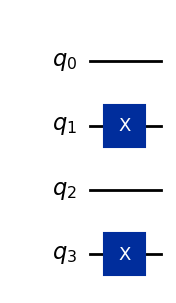

Original sample: {'temperature_c': 31.2, 'humidity_pct': 48.0, 'motion_detected': 1, 'window_open': 0}
Binary features: {'hot_room': 1, 'humid_room': 0, 'motion_detected': 1, 'window_open': 0}
Bitstring: 1010
Measurement probabilities: {np.str_('1010'): np.float64(1.0)}


In [8]:
sensor_sample = {
    "temperature_c": 31.2,
    "humidity_pct": 48.0,
    "motion_detected": 1,
    "window_open": 0,
}

# binarize the features
binary_features = {
    "hot_room": int(sensor_sample["temperature_c"] >= 30.0),
    "humid_room": int(sensor_sample["humidity_pct"] >= 60.0),
    "motion_detected": int(sensor_sample["motion_detected"]),
    "window_open": int(sensor_sample["window_open"]),
}

bits = np.array(list(binary_features.values()), dtype=int)
bitstring = "".join(str(bit) for bit in bits)  # yields "1010"

qc_basis = QuantumCircuit(4)
for qubit, bit in enumerate(reversed(bitstring)):  # Qiskit is little-endian, so the rightmost bit must be sent to qubit 0
    if bit == "1":
        qc_basis.x(qubit)

sv_basis = Statevector.from_instruction(qc_basis)
probs_basis = sv_basis.probabilities_dict()

display(qc_basis.draw("mpl"))
print("Original sample:", sensor_sample)
print("Binary features:", binary_features)
print("Bitstring:", bitstring)
print("Measurement probabilities:", probs_basis)


The bitstring above does not appear from nowhere: it comes from a preprocessing step that turns each discrete decision or thresholded feature into a binary value. Once the sample has been binarized as `1010`, basis encoding is implemented by flipping exactly those qubits whose bits are `1`.

The same idea can be implemented in PennyLane by applying `qml.PauliX` gates manually inside a QNode.


In [9]:
import pennylane as qml

pl_bits = bits.copy()
pl_dev = qml.device("default.qubit", wires=4)

@qml.qnode(pl_dev)
def manual_basis_probs(feature_bits):
    for wire, bit in enumerate(feature_bits):
        if bit == 1:
            qml.PauliX(wires=wire)
    return qml.probs(wires=range(4))

manual_probs = manual_basis_probs(pl_bits)
print("PennyLane manual-X probabilities:", np.round(manual_probs, 4))
print(qml.draw(manual_basis_probs)(pl_bits))


PennyLane manual-X probabilities: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
0: ──X─┤ ╭Probs
1: ────┤ ├Probs
2: ──X─┤ ├Probs
3: ────┤ ╰Probs


PennyLane also provides a higher-level template for this same operation: <a href="https://docs.pennylane.ai/en/stable/code/api/pennylane.BasisEmbedding.html"><code>qml.BasisEmbedding</code></a>. For reference, the main ingredients used are <a href="https://docs.pennylane.ai/en/stable/code/api/pennylane.qnode.html"><code>qml.qnode</code></a>, <a href="https://docs.pennylane.ai/en/stable/code/api/pennylane.PauliX.html"><code>qml.PauliX</code></a>, <a href="https://docs.pennylane.ai/en/stable/code/api/pennylane.BasisEmbedding.html"><code>qml.BasisEmbedding</code></a>, and <a href="https://docs.pennylane.ai/en/stable/code/api/pennylane.probs.html"><code>qml.probs</code></a>.


In [10]:
@qml.qnode(pl_dev)
def template_basis_probs(feature_bits):
    qml.BasisEmbedding(features=feature_bits, wires=range(4))
    return qml.probs(wires=range(4))

template_probs = template_basis_probs(pl_bits)
print("PennyLane BasisEmbedding probabilities:", np.round(template_probs, 4))
print(qml.draw(template_basis_probs)(pl_bits))


PennyLane BasisEmbedding probabilities: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
0: ─╭|Ψ⟩─┤ ╭Probs
1: ─├|Ψ⟩─┤ ├Probs
2: ─├|Ψ⟩─┤ ├Probs
3: ─╰|Ψ⟩─┤ ╰Probs


Because these circuits prepare a computational-basis state exactly, the measurement distribution is deterministic. That is very different from angle and amplitude encoding, where a single sample usually becomes a superposition whose information is recovered statistically through measurement.


## Practical guidance

A compact first-pass comparison is:

| Encoding | Best fit | Typical qubit cost | Preprocessing needed | Main caveat |
|---|---|---|---|---|
| Angle encoding | continuous features, NISQ-friendly variational models | about one qubit per feature in the simple version | scale features to a controlled angle range | periodicity can create aliasing if scaling is careless |
| Amplitude encoding | dense vectors when qubit count is the bottleneck | about $\lceil \log_2 d \rceil$ qubits for dimension $d$ | normalize and often pad to a power of two | arbitrary state preparation can be expensive |
| Basis encoding | binary or discrete data | one qubit per bit or encoded discrete variable | binarization, one-hot, or discrete representation | usually not natural for real-valued features |

In practice, angle encoding is often the first strong choice for classical continuous data because it is easy to interpret and to implement. Amplitude encoding is attractive when qubit efficiency is the main concern, but it should never be described as automatically cheap. Basis encoding is excellent when the data are already discrete.


<div style="background:#fff1d6;color:#111111;border-left:6px solid #d98500;padding:12px 14px;border-radius:6px;">
<b>How many qubits do I need?</b><br>
A useful rule of thumb is:<br>
- simple angle encoding: roughly one qubit per continuous feature;<br>
- amplitude encoding: roughly $\lceil \log_2 d \rceil$ qubits for a length-$d$ vector, after padding if needed;<br>
- basis encoding: roughly one qubit per binary feature or bitstring position.<br><br>
This qubit count is only the first estimate. The real design question is qubits <i>plus</i> preparation cost.
</div>


## Common pitfalls

- **Unscaled angle features**: rotation gates are periodic, so raw values can wrap around and hide meaningful differences.
- **Invisible phase encoding**: a pure phase rotation on $|0\rangle$ is often not useful unless superposition is created first.
- **Forgetting normalization**: amplitude encoding requires valid quantum states.
- **Ignoring preparation cost**: qubit compression alone does not make an encoding practical.
- **Using basis encoding for arbitrary real-valued data**: discretization may destroy useful structure if done carelessly.

A good encoding choice is rarely "the most quantum-looking one". It is the one whose assumptions match the structure of the data and the resource limits of the experiment.


### Task 4 (design): Choose an encoding strategy

For each scenario below, choose the most reasonable encoding among **angle**, **amplitude**, **basis**, or a clearly stated **mixed strategy**.

Scenario A:
- 8 continuous sensor features.
- Near-term device budget: about 8 to 10 qubits.
- You want a shallow variational model.

Scenario B:
- Binary strings of length 32.
- The task is pattern recognition on bitstrings.
- The data are already discrete.

Scenario C:
- 6 continuous tabular features and 2 yes/no flags.
- You care more about interpretability and robust preprocessing than about extreme qubit compression.

For each scenario, answer:
- the encoding choice,
- the estimated qubit count,
- the required preprocessing,
- and one technical limitation or tradeoff.

Then write 3-5 lines comparing Scenario A and Scenario C: why might two continuous-data problems still deserve different encoding decisions?


<div style="background:#e8f1ff;color:#111111;border-left:6px solid #2f6fed;padding:12px 14px;border-radius:6px;">
<b>Task 4 solution:</b> <a href="01-feature-maps-and-encoding-choices-solutions.ipynb#task4-solution">Click here for Task 4 solution</a>
</div>


## Looking ahead

So far, the encodings we studied were either separable or purely data-loading focused. The next step is to ask what happens when we deliberately build **feature interactions** into the encoding itself. That leads to **entangling feature maps** and **data re-uploading**, where the geometry of the representation becomes richer but the circuit also becomes deeper and harder to train.
